***
# <font color=green size=10>CURSO DE ESTADÍSTICA - PARTE 2</font>
***

# <font color=green>1 CONOCIENDO LOS DATOS</font>
***

## <font color=green>1.1 Dataset del proyecto</font>
***

### Encuesta Nacional por Muestreo de Hogares - 2015

La **Encuesta Nacional por Muestreo de Hogares - ENMH** en Brasil anualmente investiga, de manera permanente, características generales de la población, educación, trabajo, ingresos, vivienda y otras, con frecuencia variables, de acuerdo a las necesidades de información del país, tales como las características de migración, fecundidad, nupcialidad, salud, seguridad alimentaria, entre otros temas. La recopilación de estas estadísticas constituye, durante los 49 años de realización de la investigación, un importante instrumento para la formulación, validación y evaluación de políticas orientadas al desarrollo socioeconómico y la mejora de las condiciones de vida en Brasil.

### Fuente de los Datos

Instituto Brasileño de Geografía y Estadística (IBGE) Encuesta Nacional por Muestreo de Hogares(PNAD) en el 2015

### Variables utilizadas

> ### Ingresos
> ***

Ingresos mensuales del trabajo principal para personas de 10 años o más.

> ### Edad
> ***

Edad del residente en años en la fecha de referencia .

> ### Altura (elaboración propia)
> ***

Altura del habitante en metros.

> ### UF
> ***

Unidad Federal

|Código|Descripción|
|---|---|
|11|Rondônia|
|12|Acre|
|13|Amazonas|
|14|Roraima|
|15|Pará|
|16|Amapá|
|17|Tocantins|
|21|Maranhão|
|22|Piauí|
|23|Ceará|
|24|Rio Grande do Norte|
|25|Paraíba|
|26|Pernambuco|
|27|Alagoas|
|28|Sergipe|
|29|Bahia|
|31|Minas Gerais|
|32|Espírito Santo|
|33|Rio de Janeiro|
|35|São Paulo|
|41|Paraná|
|42|Santa Catarina|
|43|Rio Grande do Sul|
|50|Mato Grosso do Sul|
|51|Mato Grosso|
|52|Goiás|
|53|Distrito Federal|

> ### Sexo
> ***

|Código|Descripción|
|---|---|
|0|Masculino|
|1|Femenino|

> ### Años de Estudio
> ***

|Código|Descripción|
|---|---|
|1|Sin educación o menos de 1 año|
|2|1 año|
|3|2 años|
|4|3 años|
|5|4 años|
|6|5 años|
|7|6 años|
|8|7 años|
|9|8 años|
|10|9 años|
|11|10 años|
|12|11 años|
|13|12 años|
|14|13 años|
|15|14 años|
|16|15 años o más|
|17|No determinado|
||No aplica|

> ### Color
> ***

|Código|Descripción|
|---|---|
|0|Indígena|
|2|Blanco|
|4|Negro|
|6|Amarillo|
|8|Pardo|
|9|Sin declarar|

#### <font color='red'>Nota</font>
***
> Se realizaron los siguientes tratamientos sobre los datos originales:
> 1. Se eliminaron los registros en los que **Ingreso** no era válido. (999 999 999 999);
> 2. Se eliminaron los registros en los que **Ingreso** eran missing;
> 3. Solo se consideraron los registros de **Personas de Referencia** de cada hogar (responsable del hogar).

### Importando pandas y leyendo el dataset del proyecto

https://pandas.pydata.org/

In [141]:
import pandas as pd

In [142]:
datos = pd.read_csv('datos bra.csv', encoding='latin-1')

In [143]:
datos.head()

,Ciudad,Sexo,Edad,Color,Años de Estudio,Ingreso,Altura
0,11,0,23,8,12,800,1.603808
1,11,1,23,2,12,1150,1.739790
2,11,1,35,8,15,880,1.760444
3,11,0,46,2,6,3500,1.783158
4,11,1,47,8,9,150,1.690631


---
---

# <font color=green>2 DISTRIBUCIONES DE PROBABILIDAD</font>
***

## <font color=red>Problema</font>
***

En una competencia para ocupar un puesto de científico de datos, tenemos un total de **10 preguntas** de opción múltiple con **3 alternativas posibles** en cada pregunta. **Cada pregunta tiene el mismo valor.** Suponga que un candidato decide aventurarse sin haber estudiado nada. Decide hacer la prueba con los ojos vendados y adivinar todas las respuestas. Suponiendo que la prueba **vale 10 puntos y la puntuación de corte es 5**, obtenga la probabilidad de que este candidato **acierte 5 preguntas** y también la probabilidad de que el candidato **pase a la siguiente etapa del proceso de selección**.

## <font color=green>2.1 Distribución Binomial</font>
***

Un evento **binomial** se caracteriza por la posibilidad de que solo ocurran dos categorías. Estas categorías juntas representan todo el espacio muestral, siendo también mutuamente excluyentes, es decir, la ocurrencia de una implica la no ocurrencia de la otra.

En el análisis estadístico, el uso más común de la distribución binomial es para resolver problemas que involucran situaciones de **éxito** y **fracaso**.

 $$P(k)=\binom{n}{k} p^k q^{n-k}$$

Donde:

$p$ = probabilidad de éxito

$q = (1 - p)$ = probabilidad de fracaso

$n$ = número de eventos estudiados

$k$ = número de eventos deseados que tienen éxito

### Experimento Binomial

1. Realización de $n$ pruebas idénticas.

2. Las pruebas son independientes.

3. Solo son posibles dos resultados, por ejemplo: Verdadero o falso; Cara o cruz; Éxito o fracaso.

4. La probabilidad de éxito está representada por $p$ y la probabilidad de fracaso por $1-p = q$. Estas probabilidades no cambian de una prueba para otra.

### Media de la distribución binomial

El valor esperado o la media de la distribución binomial es igual al número de experimentos realizados multiplicado por la probabilidad de que ocurra el evento.

 $$\mu = n \times p$$

### Desviación estándar de la distribución binomial

La desviación estándar es la raíz quadrada del producto entre el número de experimentos, la probabilidad de éxito y la probabilidad de fracaso.

 $$\sigma = \sqrt{n \times p \times q}$$

### Importando bibliotecas
https://docs.scipy.org/doc/scipy/reference/generated/scipy.special.comb.html

In [144]:
from scipy.special import comb

### Combinaciones

El número de combinaciones de $n$ objetos, tomando $k$ cada vez, es:

# $$C_{k}^{n} = \binom{n}{k} = \frac{n!}{k!(n - k)!}$$

Donde

## $$n! = n\times(n-1)\times(n-2)\times...\times(2)\times(1)$$
## $$k! = k\times(k-1)\times(k-2)\times...\times(2)\times(1)$$

Por definición

## $$0! = 1$$

 <font color='blue'>Ejemplo: Mega Sena</font>

En una rueda de lotería Mega Sena tenemos un total de **60 números** para elegir, donde la apuesta mínima es de **seis números**. Usted que es curioso(a) decide calcular la probabilidad de ganar la Mega Sena con solo **un juego**. Para eso necesitamos saber cuántas **combinaciones de seis números se pueden formar con los 60 números disponibles**.

### $$C_{6}^{60} = \binom{60}{6} = \frac{60!}{6!(60 - 6)!}$$

In [145]:
combinaciones = comb(60,6)
combinaciones

50063860.0

In [146]:
probabilidad = (1/combinaciones)
print(f'{probabilidad :0.15f}')

0.000000019974489


In [147]:
combinaciones = comb(25,20)
combinaciones

53130.0

In [148]:
probabilidad = 1/combinaciones
print(f'{probabilidad:0.15f}')

0.000018821757952


 <font color='blue'>Ejemplo: Concurso para científico de datos</font>

En una competencia para ocupar un puesto de científico de datos, tenemos un total de **10 preguntas** de opción múltiple con **3 alternativas posibles** en cada pregunta. **Cada pregunta tiene el mismo valor.** Suponga que un candidato decide aventurarse sin haber estudiado nada. Decide tomar la prueba con los ojos vendados y adivinar todas las respuestas. Suponiendo que la prueba **vale 10 puntos y la puntuación de corte es 5**, obtenga la probabilidad de que este candidato **acierte 5 preguntas** y también la probabilidad de que el candidato **pase a la siguiente etapa del proceso de selección**.

### ¿Cuál es la cantidad de pruebas ($n$)?

In [149]:
n = 10
n

10

### ¿Las pruebas son independientes?

Sí. La opción elegida en una pregunta no influye en la opción elegida en otra pregunta.

### ¿Sólo dos resultados son posibles en cada prueba?

Sí. El candidato tiene dos posibilidades, ACERTAR o FALLAR una pregunta.

### ¿Cuál es la probabilidad de éxito ($p$)?

In [150]:
numero_alter_pregunta = 3
p = (1 / numero_alter_pregunta)
p

0.3333333333333333

### ¿Cuál es la probabilidad de fracaso ($q$)?

In [151]:
q = 1 - p
q

0.6666666666666667

### ¿Cuál es el número total de eventos para tener éxito ($k$)?

In [152]:
k = 5
k

5

### Solución 1

In [153]:
probabilidad = (comb(10,5) * (p ** k)* (q ** (n - k)))
print(f'{probabilidad:.8f}')

0.13656455


### Importando bibliotecas
https://docs.scipy.org/doc/scipy/reference/generated/scipy.stats.binom.html

In [154]:
from scipy.stats import binom

### Solución 2

In [155]:
probabilidad = binom.pmf(k,n,p)
print(f'{probabilidad:.8f}')

0.13656455


### Obtenga la probabilidad de que el candidato apruebe

### $$P(acertar \geq 5) = P(5) + P(6) + P(7) + P(8) + P(9) + P(10)$$

In [156]:
probabilidad = binom.pmf(5,n,p) + binom.pmf(6,n,p) + binom.pmf(7,n,p) +binom.pmf(8,n,p) + binom.pmf(9,n,p) + binom.pmf(10,n,p)
probabilidad

0.21312808006909476

In [157]:
binom.cdf(4,n,p)

0.7868719199309048

In [158]:
1 - binom.cdf(4,n,p)

0.21312808006909523

In [159]:
binom.sf(4,n,p)

0.21312808006909525

In [160]:
p = 1 / 2  # Probabilidad de salir CRUZ
n = 4          # Total de lanzamientos
k = 2          # Total de aciertos (CRUZ hacia arriba)

binom.pmf(k, n, p)

0.375

In [161]:
p = 1 / 6   # Probabilidad de salir el número CINCO
n = 10      # Total de lanzamientos

print(f'{binom.sf(2, n, p):.2%}')

22.48%


 <font color='blue'>Ejemplo: Yincana</font>

Una ciudad del interior realiza una yincana cada año para recaudar fondos para el hospital de la ciudad. En la última competencia se sabe que la **proporción de mujeres participantes fue del 60%**. **El número total de equipos, con 12 miembros, inscritos en la yincana de este año es 30**. Con la información anterior, responda: ¿Cuántos equipos deberían estar formados por **8 mujeres**?

### Solución

In [162]:
p = 0.6
p

0.6

In [163]:
n = 12
n

12

In [164]:
k = 8
k

8

In [165]:
probabiliad_mujeres = binom.pmf(k,n,p)
print(f'{probabiliad_mujeres:.8f}')

0.21284094


In [166]:
equipos = 30 * probabiliad_mujeres
equipos.round(2)

6.39

In [167]:
# Suponga que la probabilidad de que una pareja tenga hijos con ojos azules es del 22%. En 50 familias,
# con 3 hijos cada una, ¿cuántas podemos esperar que tengan dos hijos con ojos azules?
p = 0.22
n = 3
k = 2
N = 50

probabilidad = binom.pmf(k, n, p)

media = probabilidad * N

media.round(2)

5.66

---
---

## <font color=red>Problema</font>
***

Un restaurante recibe un promedio de **20 pedidos por hora**. ¿Cuál es la probabilidad de que, en un momento determinado al azar, el restaurante reciba **15 pedidos**?

## <font color=green>2.2 Distribución Poisson</font>
***

Se utiliza para describir el número de ocurrencias en un tiempo o espacio específico. Los eventos se caracterizan por la posibilidad de contar los éxitos, pero no poder contar los fracasos.

Como ejemplos de procesos donde podemos aplicar la distribución de Poisson tenemos la determinación del número de clientes que ingresan a una tienda en un momento determinado, el número de autos que llegan a un Auto-servicio de una cafetería a la hora del almuerzo, la determinación del número de accidentes registrados en un tramo de carretera, etc.

 $$P(k) = \frac{e^{-\mu}(\mu)^k}{k!}$$

Donde:

$e$ = constante cuyo valor aproximado es 2.718281828459045

$\mu$ = representa el número promedio de ocurrencias en un intervalo de tiempo o espacio dado

$k$ = número de éxitos en el intervalo deseado

### Experimento Poisson

1. La probabilidad de que ocurra es la misma en todo el intervalo observado.

2. El número de ocurrencias en un intervalo dado es independiente del número de ocurrencias en otros intervalos.

3. La probabilidad de que ocurra es la misma en intervalos de igual longitud.

### Media de la distribución Poisson

 $$\mu$$

### Desviación estándar de la distribución Poisson

 $$\sigma = \sqrt{\mu}$$

### Importando bibliotecas

http://www.numpy.org/

In [168]:
import numpy as np

In [169]:
np.e

2.718281828459045

 <font color='blue'>Ejemplo: Delivery</font>

Un restaurante recibe un promedio de **20 pedidos por hora**. ¿Cuál es la probabilidad de que, en un momento determinado al azar, el restaurante reciba **15 pedidos**?

### ¿Cuál es el número promedio de ocurrencias por hora ($\mu$)?

In [170]:
media = 20
media

20

### ¿Qué número de ocurrencias queremos obtener en el período ($k$)?

In [171]:
k = 15
k

15

### Solución 1

In [172]:
probabilidad = ((np.e ** (- media)) * (media ** k)) / (np.math.factorial(k))
print(f'{probabilidad}')

0.0516488535317584


### Importando bibliotecas

https://docs.scipy.org/doc/scipy/reference/generated/scipy.stats.poisson.html

### Solución 2

In [173]:
from scipy.stats import poisson

probabiblidad = poisson.pmf(k,media)
print(f'{probabilidad}')

0.0516488535317584


In [174]:
'''El número media de clientes que ingresan a una panadería por hora es 20.
Obtenga la probabilidad de que, en la próxima hora,
ingresen exactamente 25 clientes.'''

from scipy.stats import poisson

media = 20
k= 25
probabiblidad = poisson.pmf(k,media)
print(f'{probabiblidad}')

0.04458764910826764


---
---

## <font color=red>Problema</font>
***

En un estudio sobre la altura de los residentes de una ciudad, se encontró que el conjunto de datos sigue una **distribución aproximadamente normal**, con **media 1.70** y **desviación estándar de 0.1**. Con esta información, obtenga el siguiente conjunto de probabilidades:

> **A.** probabilidad de que una persona, seleccionada al azar, sea menor de 1.80 metros.

> **B.** probabilidad de que una persona, seleccionada al azar, tenga entre 1.60 metros y 1.80 metros.

> **C.** probabilidad de que una persona, seleccionada al azar, tenga más de 1.90 metros.


## <font color=green>2.3 Distribución Normal</font>
***

La distribución normal es una de las más utilizadas en estadística. Es una distribución continua, donde la distribución de frecuencias de una variable cuantitativa tiene forma de campana y es simétrica en relación con su media.

<img src='https://caelum-online-public.s3.amazonaws.com/ESP-1764-estadistica-con-python-probabilidad-y-muestreo/img001.png' width='500px'>

### Características importantes

1. Es simétrica alrededor de la media;

2. El área bajo la curva corresponde a la proporción 1 o 100%;

3. Las medidas de tendencia central (media, mediana y moda) tienen el mismo valor;

4. Los extremos de la curva tienden al infinito en ambas direcciones y, teóricamente, nunca tocan el eje $x$;

5. La desviación estándar define la planitud y el ancho de la distribución. Las curvas más anchas y planas tienen valores de desviación estándar más altos;

6. La distribución se define por su media y desviación estándar;

7. La probabilidad siempre será igual al área bajo la curva, delimitada por los límites superior e inferior.

 $$f(x) = \frac{1}{\sqrt{2\pi\sigma}}e^{-\frac{1}{2}\left(\frac{x-\mu}{\sigma}\right)^2}$$

Donde:

$x$ = variable normal

$\sigma$ = desviación estándar

$\mu$ = media

La probabilidad se obtiene del área bajo la curva, delimitada por los límites superior e inferior especificados. Se puede ver un ejemplo en la figura siguiente.

<img src='https://caelum-online-public.s3.amazonaws.com/ESP-1764-estadistica-con-python-probabilidad-y-muestreo/img002.png' width='500px'>


Para obtener el área anterior, simplemente calcule la integral de la función para los intervalos determinados. Según la siguiente ecuación:

 $$P(L_i<x<L_s) = \int_{L_i}^{L_s}\frac{1}{\sqrt{2\pi\sigma}}e^{-\frac{1}{2}\left(\frac{x-\mu}{\sigma}\right)^2}$$

Donde:

$x$ = variable normal

$\sigma$ = desviación estándar

$\mu$ = media

$L_i$ = límite inferior

$L_s$ = límite superior

### Tablas estandarizadas

Se crearon tablas estandarizadas para facilitar la obtención de los valores de las áreas bajo la curva normal y eliminar la necesidad de resolver integrales definidas.

Para ver los valores en una tabla estandarizada, simplemente transforme nuestra variable en una variable estandarizada $Z$.

Esta variable $Z$ representa la desviación en las desviaciones estándar de un valor de la variable original en relación con la media.

 $$Z = \frac{x-\mu}{\sigma}$$

Donde:

$x$ = variable normal con media $\mu$ y desviación estándar $\sigma$

$\sigma$ = desviación estándar

$\mu$ = media

### Construyendo la tabla normal estandarizada
https://docs.scipy.org/doc/scipy/reference/generated/scipy.stats.norm.html

In [175]:
import pandas as pd
import numpy as np
from scipy.stats import norm

tabla_normal_estandarizada = pd.DataFrame(
    [],
    index=["{0:0.2f}".format(i / 100) for i in range(0, 400, 10)],
    columns = ["{0:0.2f}".format(i / 100) for i in range(0, 10)])

for index in tabla_normal_estandarizada.index:
    for column in tabla_normal_estandarizada.columns:
        Z = np.round(float(index) + float(column), 2)
        tabla_normal_estandarizada.loc[index, column] = "{0:0.4f}".format(norm.cdf(Z))

tabla_normal_estandarizada.rename_axis('Z', axis = 'columns', inplace = True)

tabla_normal_estandarizada

Z,0.00,0.01,0.02,0.03,0.04,0.05,0.06,0.07,0.08,0.09
0.00,0.5000,0.5040,0.5080,0.5120,0.5160,0.5199,0.5239,0.5279,0.5319,0.5359
0.10,0.5398,0.5438,0.5478,0.5517,0.5557,0.5596,0.5636,0.5675,0.5714,0.5753
0.20,0.5793,0.5832,0.5871,0.5910,0.5948,0.5987,0.6026,0.6064,0.6103,0.6141
0.30,0.6179,0.6217,0.6255,0.6293,0.6331,0.6368,0.6406,0.6443,0.6480,0.6517
0.40,0.6554,0.6591,0.6628,0.6664,0.6700,0.6736,0.6772,0.6808,0.6844,0.6879
0.50,0.6915,0.6950,0.6985,0.7019,0.7054,0.7088,0.7123,0.7157,0.7190,0.7224
0.60,0.7257,0.7291,0.7324,0.7357,0.7389,0.7422,0.7454,0.7486,0.7517,0.7549
0.70,0.7580,0.7611,0.7642,0.7673,0.7704,0.7734,0.7764,0.7794,0.7823,0.7852
0.80,0.7881,0.7910,0.7939,0.7967,0.7995,0.8023,0.8051,0.8078,0.8106,0.8133
0.90,0.8159,0.8186,0.8212,0.8238,0.8264,0.8289,0.8315,0.8340,0.8365,0.8389


<img src='https://caelum-online-public.s3.amazonaws.com/ESP-1764-estadistica-con-python-probabilidad-y-muestreo/img003.png' width='250px'>

La tabla anterior proporciona el área bajo la curva entre $-\infty$ y $Z$ desviaciones estándar por encima de la media. Recordando que dado que estos son valores estandarizados, tenemos $\mu = 0$.

<font color='blue'>Ejemplo: ¿Cuánto mides?</font>

En un estudio sobre la altura de los residentes de una ciudad, se encontró que el conjunto de datos sigue una **distribución aproximadamente normal**, con **media 1.70** y **desviación estándar de 0.1**. Con esta información, obtenga el siguiente conjunto de probabilidades:

> **A.** probabilidad de que una persona, seleccionada al azar, mida menos que 1.80 metros.

> **B.** probabilidad de que una persona, seleccionada al azar, mida entre 1.60 metros y 1.80 metros.

> **C.** probabilidad de que una persona, seleccionada al azar, mida más de 1.90 metros.

### Problema A - Identificación del área bajo la curva

<img style='float: left' src='https://caelum-online-public.s3.amazonaws.com/ESP-1764-estadistica-con-python-probabilidad-y-muestreo/img004.png' width='350px'>


### Obtener la variable estandarizada $Z$

In [176]:
media = 1.70
media

1.7

In [177]:
desviacion_estandar = 0.1
desviacion_estandar

0.1

In [178]:
z =  (1.80 - media)/desviacion_estandar
z

1.0000000000000009

### Solución 1 - Utilizando la tabla

In [179]:
probabilidad = 0.8413
probabilidad

0.8413

### Solución 2 - Utilizando Scipy

In [180]:
from scipy.stats import norm
media = 1.70
desviacion_estandar = 0.1
z =  (1.80 - media)/desviacion_estandar
norm.cdf(z)

0.8413447460685431

La aplicación de una prueba Estadística en una competencia presentó un conjunto de notas normalmente distribuidas. Se encontró que el conjunto de notas tenía una media de 70 y una desviación estándar de 5 puntos.

1. ¿Qué probabilidad hay de que un estudiante, seleccionado al azar, obtenga una puntuación inferior a 85 puntos?

In [181]:
from scipy.stats import norm
media = 70
desviacion_estandar = 5
z =  (85 - media)/desviacion_estandar
norm.cdf(z)

0.9986501019683699

### Problema B - Identificación del área bajo la curva

<img style='float: left' src='https://caelum-online-public.s3.amazonaws.com/ESP-1764-estadistica-con-python-probabilidad-y-muestreo/img005.png' width='350px'>

### Obtener la variable estandarizada $Z$

In [182]:
media = 1.70
desviacion_estandar = 0.1
z =  (1.7 - media)/desviacion_estandar
z

0.0

In [183]:
norm.cdf(z)

0.5

In [184]:
media = 1.70
desviacion_estandar = 0.1
z =  (1.8 - media)/desviacion_estandar
z

1.0000000000000009

In [185]:
norm.cdf(z)

0.8413447460685431

### Solución 1 - Utilizando la tabla

In [186]:
probabilidad =  (0.8413 - 0.5000)*2
probabilidad

0.6826000000000001

### Solución 2 - Utilizando Scipy

In [187]:
media = 1.70
desviacion_estandar = 0.1
z_superior =  (1.8 - media)/desviacion_estandar
probabilidad =  norm.cdf(z_superior) -(1-norm.cdf(z_superior))
probabilidad

0.6826894921370863

In [188]:
media = 1.70
desviacion_estandar = 0.1
z_inferior =  (1.6 - media)/desviacion_estandar
probabilidad =  norm.cdf(z_superior ) - (norm.cdf(z_inferior ))
probabilidad

0.6826894921370857

La facturación diaria de un controlador de aplicación sigue una distribución aproximadamente normal, con un media de  300,00 y una desviación estándar igual a  50,00. Obtenga las probabilidades de que, en un día aleatorio, el conductor gane:

1.  Entre  250,00 y  350,00

2.  Entre  400,00 y  500,00

In [189]:
media = 300
desviacion_estandar = 50
Z_inferior = (250 - media) / desviacion_estandar
Z_superior = (350 - media) / desviacion_estandar

probabilidad = norm.cdf(Z_superior) - norm.cdf(Z_inferior)
print(f'{probabilidad:.2%}')

68.27%


In [190]:
media = 300
desviacion_estandar = 50
Z_inferior = (400 - media) / desviacion_estandar
Z_superior = (500 - media) / desviacion_estandar

probabilidad = norm.cdf(Z_superior) - norm.cdf(Z_inferior)
print(f'{probabilidad:.2%}')

2.27%


### Problema C - Identificación del área bajo la curva

<img style='float: left' src='https://caelum-online-public.s3.amazonaws.com/ESP-1764-estadistica-con-python-probabilidad-y-muestreo/img006.png' width='350px'>

### Obtener la variable estandarizada $Z$

In [191]:
media = 1.70
desviacion_estandar = 0.1

z =  (1.9 - media)/desviacion_estandar

### Solución 1 - Utilizando la tabla

In [192]:
probabiblidad = 1 - 0.9776
probabiblidad

0.022399999999999975

### Solución 2 - Utilizando Scipy

In [193]:
probabiblidad = 1 - norm.cdf(z)
probabiblidad

0.02275013194817921

In [194]:
probabiblidad = norm.cdf(-z)
probabiblidad

0.022750131948179216

Una empresa verificó que las lámparas incandescentes XPTO tienen una vida útil normalmente distribuida, con un media igual a 720 días y una desviación estándar igual a 30 días. Calcula la probabilidad de que una lámpara, elegida al azar, dure:

1. Entre 650 y 750 días

2. Más de 800 días

3. Menos de 700 días

In [195]:
media = 720
desviacion_estandar = 30

# Item A
Z_inferior = (650 - media) / desviacion_estandar
Z_superior = (750 - media) / desviacion_estandar

probabilidad = norm.cdf(Z_superior) - norm.cdf(Z_inferior)
print(f'{probabilidad:.2%}')

# Item B
Z = (800 - media) / desviacion_estandar

probabilidad = 1 - norm.cdf(Z)
print(f'{probabilidad:.2%}')

# Item C
Z = (700 - media) / desviacion_estandar

probabilidad = norm.cdf(Z)
print(f'{probabilidad:.2%}')

83.15%
0.38%
25.25%


Usando la tabla estandarizada, o las herramientas proporcionadas por Python, encuentre el área debajo de la curva normal para los valores Z a continuación:

1. Z < 1,96

2. Z > 2,15

3. Z < -0,78

4. Z > 0,59

In [196]:
# Item A
probabilidad = norm.cdf(1.96)
print(f'{probabilidad:0.4f}')

# Item B
probabilidad = 1 - norm.cdf(2.15)
# o -> probabilidad = norm.sf(2.15)
print(f'{probabilidad:0.4f}')

# Item C
probabilidad = norm.cdf(-0.78)
print(f'{probabilidad:0.4f}')

# Item D
probabilidad = 1 - norm.cdf(0.59)
# o -> probabilidad = norm.sf(0.59)
print(f'{probabilidad:0.4f}')

0.9750
0.0158
0.2177
0.2776


# <font color=green>3 MUESTREO</font>
***

## <font color=green>3.1 Población y Muestra</font>
***

### Población
Conjunto de todos los elementos de interés de un estudio. Varios elementos pueden componer una población, por ejemplo: personas, edades, alturas, automóviles, etc.

En cuanto al tamaño, las poblaciones pueden ser limitadas (poblaciones finitas) o ilimitadas (poblaciones infinitas).

### Poblaciones finitas

Permiten el recuento de sus elementos. Los ejemplos incluyen el número de empleados en una empresa, el número de estudiantes en una escuela, etc.

### Poblaciones infinitas

No es posible contar sus elementos. Como ejemplos tenemos el número de porciones que se pueden extraer del agua del mar para su análisis, la temperatura medida en cada punto de un territorio, etc.

<font color=red>Cuando se pueden contar los elementos de una población, pero presentando una cantidad muy grande, se supone que la población es infinita.</font>

### Muestra
Subconjunto representativo de la población.

Los atributos numéricos de una población, como su media, varianza y desviación estándar, se conocen como **parámetros**. El enfoque principal de la inferencia estadística es precisamente generar estimaciones y probar hipótesis sobre parámetros poblacionales utilizando información de la muestra.

## <font color=green>3.2 ¿Cuándo usar una muestra?</font>
***

### Poblaciones infinitas

El estudio nunca llegaría a su fin. No es posible investigar todos los elementos de la población.

### Pruebas destructivas

Estudios donde los elementos evaluados son totalmente consumidos o destruidos. Ejemplo: pruebas de vida útil, pruebas de seguridad en accidentes de tráfico.

### Resultados rápidos

Investigaciones que necesitan más agilidad en la difusión. Ejemplo: encuestas de opinión, encuestas sobre problemas de salud pública.

### Altos precios

Cuando la población es finita pero muy grande, el costo de un censo puede hacer inviable el proceso.

1. Cuando se pueden contabilizar los elementos de una población, pero tienen una cantidad muy grande, se supone que la población es infinita.

2. Los estudios que involucren poblaciones infinitas deben realizarse utilizando muestras.

## <font color=green>3.3 Muestreo Aleatorio Simple</font>
***

Es una de las principales formas de extraer una muestra de una población. El requisito fundamental de este tipo de enfoque es que cada elemento de la población tenga las mismas posibilidades de ser seleccionado para formar parte de la muestra.

In [197]:
datos.head()

,Ciudad,Sexo,Edad,Color,Años de Estudio,Ingreso,Altura
0,11,0,23,8,12,800,1.603808
1,11,1,23,2,12,1150,1.739790
2,11,1,35,8,15,880,1.760444
3,11,0,46,2,6,3500,1.783158
4,11,1,47,8,9,150,1.690631


In [198]:
datos.shape[0]

76840

In [199]:
datos.Ingreso.mean()

2000.3831988547631

In [200]:
muestra = datos.sample(n = 1000, random_state= 101)

In [201]:
muestra.shape[0]

1000

In [202]:
muestra.Ingreso.mean()

1998.783

In [203]:
datos.Sexo.value_counts(normalize=True)*100

0    69.299844
1    30.700156
Name: Sexo, dtype: float64

In [204]:
muestra.Sexo.value_counts(normalize=True)*100

0    70.6
1    29.4
Name: Sexo, dtype: float64

## <font color=green>3.4 Muestreo Estratificado</font>
***

Es una mejora del proceso de muestreo aleatorio simple. En este método, se propone dividir la población en subgrupos de elementos con características similares, es decir, grupos más homogéneos. Con estos subgrupos separados, la técnica de muestreo aleatorio simple dentro de cada subgrupo se aplica individualmente.

## <font color=green>3.5 Muestreo por Conglomerados</font>
***

También tiene como objetivo mejorar el criterio de muestreo aleatorio simple. En el muestreo por conglomerados también se crean subgrupos, pero no serán homogéneos como en el muestreo estratificado. En el muestreo por conglomerados los subgrupos serán heterogéneos, donde luego se aplicará un muestreo aleatorio simple o estratificado.

Un ejemplo muy común de la aplicación de este tipo de técnica es la división de la población en grupos territoriales, donde los elementos investigados tendrán características bastante variadas.

# <font color=green>4 ESTIMACIÓN</font>
***

 <font color='red'>Problema </font>

Suponga que los pesos de las bolsas de arroz de una industria alimentaria se distribuyen aproximadamente como una distribución normal **desviación estándar igual a 150 g**. Se seleccionó una **muestra aleatoria de 20 bolsas** de un lote específico, se obtuvo un **peso promedio de 5.050 g**. Construya un **intervalo de confianza para la media de la población** asumiendo un **nivel de significancia del 5%**.

---

Es la forma de hacer suposiciones generalizadas sobre los parámetros de una población a partir de información de una muestra.

- **Los parámetros** son los atributos numéricos de una población, como la media, la desviación estándar, etc.

- **Estimación** es el valor obtenido para un parámetro dado a partir de los datos de una muestra de la población.

## <font color=green>4.1 Teorema central del límite</font>
***

> El **Teorema Central del Límite** establece que, con el aumento del tamaño de la muestra, la distribución de las medias muestrales se aproxima a una distribución normal con media igual a la media de la población y una desviación estándar igual a la desviación estándar de la variable original dividida por la raíz cuadrada del tamaño de la muestra. Este hecho está asegurado para $n$ mayores o iguales a 30.

 $$\sigma_\bar{x} = \frac{\sigma}{\sqrt{n}}$$

La desviación estándar de las medias muestrales se conoce como **error estándar de la media**

### Entendiendo el Teorema Central del Límite

In [205]:
n = 2000
total_muestra = 1500

In [206]:
muestra = pd.DataFrame()
muestra

""


In [207]:
for i in range(total_muestra):
  _ = datos.Edad.sample(n)
  _.index = range(0,len(_))
  muestra['Muestra_' + str(i)] = _

muestra

<ipython-input-207-67a0fc7186e7>:4: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  muestra['Muestra_' + str(i)] = _
<ipython-input-207-67a0fc7186e7>:4: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  muestra['Muestra_' + str(i)] = _
<ipython-input-207-67a0fc7186e7>:4: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame

,Muestra_0,Muestra_1,Muestra_2,Muestra_3,Muestra_4,Muestra_5,Muestra_6,Muestra_7,Muestra_8,Muestra_9,...,Muestra_1490,Muestra_1491,Muestra_1492,Muestra_1493,Muestra_1494,Muestra_1495,Muestra_1496,Muestra_1497,Muestra_1498,Muestra_1499
0,39,44,29,59,49,70,59,34,39,36,...,50,41,35,48,33,40,43,50,54,29
1,33,75,37,52,48,37,44,38,50,46,...,50,32,56,57,55,35,50,50,25,51
2,38,38,38,60,47,44,58,35,39,26,...,70,51,36,64,60,63,45,44,26,43
3,49,52,37,52,52,39,70,38,26,55,...,25,31,48,29,71,50,35,50,41,46
4,51,46,47,55,45,31,60,45,46,39,...,37,47,47,32,22,33,24,48,65,51
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1995,38,52,43,31,30,34,53,48,29,45,...,51,50,32,65,46,60,41,54,57,52
1996,48,28,27,32,37,34,41,50,24,54,...,50,43,49,61,32,28,51,39,52,53
1997,31,56,58,36,61,39,31,35,56,35,...,39,66,40,42,44,52,45,55,35,26
1998,50,44,45,36,56,51,54,44,37,39,...,50,31,54,52,30,51,51,39,42,35


In [208]:
muestra.mean()

Muestra_0       44.0280
Muestra_1       44.2680
Muestra_2       43.5005
Muestra_3       44.1180
Muestra_4       44.2320
                 ...   
Muestra_1495    44.1145
Muestra_1496    43.7060
Muestra_1497    43.8925
Muestra_1498    43.8740
Muestra_1499    44.2135
Length: 1500, dtype: float64

> El **Teorema Central del Límite** establece que, con el aumento del tamaño de la muestra, la distribución de las medias muestrales se aproxima a una distribución normal con media igual a la media de la población y una desviación estándar igual a la desviación estándar de la variable original dividida por la raíz cuadrada del tamaño de la muestra. Este hecho está asegurado para $n$ mayores o iguales a 30.

<Axes: >

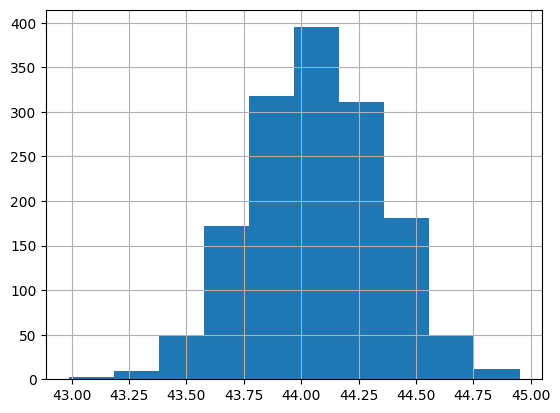

In [209]:
muestra.mean().hist()

> El **Teorema Central del Límite** establece que, con el aumento del tamaño de la muestra, la distribución de las medias muestrales se aproxima a una distribución normal con media igual a la media de la población y una desviación estándar igual a la desviación estándar de la variable original dividida por la raíz cuadrada del tamaño de la muestra. Este hecho está asegurado para $n$ mayores o iguales a 30.

In [210]:
datos.Edad.mean()

44.07142113482561

In [211]:
muestra.mean().mean()

44.069151000000005

> El **Teorema Central del Límite** establece que, con el aumento del tamaño de la muestra, la distribución de las medias muestrales se aproxima a una distribución normal con media igual a la media de la población y una desviación estándar igual a la desviación estándar de la variable original dividida por la raíz cuadrada del tamaño de la muestra. Este hecho está asegurado para $n$ mayores o iguales a 30.

 $$\sigma_\bar{x} = \frac{\sigma}{\sqrt{n}}$$

In [212]:
muestra.mean().std()

0.2856022662176295

In [213]:
datos.Edad.std()

12.48058346535974

In [214]:
datos.Edad.std() / np.sqrt(n)

0.27907433027404266

## <font color=green>4.2 Los niveles de confianza y significación</font>
***

El **nivel de confianza** ($1 - \alpha$) representa la probabilidad de que la estimación sea correcta. Además, el **nivel de significancia** ($\alpha$) expresa la probabilidad de error de la estimación.

El **nivel de confianza** representa el grado de confiabilidad del resultado estimado dentro de un cierto rango. Cuando establecemos un **nivel de confianza del 95%** en una encuesta, por ejemplo, estamos asumiendo que existe una probabilidad del 95% de que los resultados de la encuesta representen bien la realidad, es decir, sean correctos.

El **nivel de confianza** de una estimación se puede obtener del área bajo la curva normal como se muestra en la figura siguiente.

<img src='https://caelum-online-public.s3.amazonaws.com/ESP-1764-estadistica-con-python-probabilidad-y-muestreo/img007.png' width='450px'>


## <font color=green>4.3 Error inferencial</font>
***

El **error inferencial** se define por la **desviación estándar de las medias muestrales** $\sigma_\bar{x}$ y por el **nivel de confianza** determinado para el proceso.

 $$e = z \frac{\sigma}{\sqrt{n}}$$

## <font color=green>4.4 Intervalos de confianza</font>
***

### Intervalo de confianza para la media poblacional

#### Con desviación estándar poblacional conocida

## $$\mu = \bar{x} \pm z\frac{\sigma}{\sqrt{n}}$$

#### Con desviación estándar de población desconocida

## $$\mu = \bar{x} \pm z\frac{s}{\sqrt{n}}$$

## <font color='blue'>Ejemplo: </font>

Suponga que los pesos de las bolsas de arroz de una industria alimentaria se distribuyen aproximadamente como una población normal con **desviación estándar igual a 150 g**. Se seleccionó una **muestra aleatoria de 20 bolsas** de un lote específico, se obtuvo un **peso promedio de 5050 g**. Construya un intervalo de confianza para el **promedio de la población** asumiendo un **nivel de significancia del 5%**.

### Media muestral

In [215]:
media_muestra = 5050
media_muestra

5050

### Nivel de significancia ($\alpha$)

In [216]:
significancia = 0.05
significancia

0.05

### Nivel de confianza ($1 - \alpha$)

In [217]:
nivel_confianza = 1- significancia
nivel_confianza

0.95

### Obteniendo $z$

In [218]:
tabla_normal_estandarizada[16:26]

Z,0.00,0.01,0.02,0.03,0.04,0.05,0.06,0.07,0.08,0.09
1.60,0.9452,0.9463,0.9474,0.9484,0.9495,0.9505,0.9515,0.9525,0.9535,0.9545
1.70,0.9554,0.9564,0.9573,0.9582,0.9591,0.9599,0.9608,0.9616,0.9625,0.9633
1.80,0.9641,0.9649,0.9656,0.9664,0.9671,0.9678,0.9686,0.9693,0.9699,0.9706
1.90,0.9713,0.9719,0.9726,0.9732,0.9738,0.9744,0.9750,0.9756,0.9761,0.9767
2.00,0.9772,0.9778,0.9783,0.9788,0.9793,0.9798,0.9803,0.9808,0.9812,0.9817
2.10,0.9821,0.9826,0.9830,0.9834,0.9838,0.9842,0.9846,0.9850,0.9854,0.9857
2.20,0.9861,0.9864,0.9868,0.9871,0.9875,0.9878,0.9881,0.9884,0.9887,0.9890
2.30,0.9893,0.9896,0.9898,0.9901,0.9904,0.9906,0.9909,0.9911,0.9913,0.9916
2.40,0.9918,0.9920,0.9922,0.9925,0.9927,0.9929,0.9931,0.9932,0.9934,0.9936
2.50,0.9938,0.9940,0.9941,0.9943,0.9945,0.9946,0.9948,0.9949,0.9951,0.9952


### Obteniendo $z$

<img src='https://caelum-online-public.s3.amazonaws.com/ESP-1764-estadistica-con-python-probabilidad-y-muestreo/img008.png' width='450px'>

In [219]:
(0.95 / 2)*100

47.5

In [220]:
(0.5 + 0.95 / 2)*100

97.5

In [221]:
z = 1.96
z

1.96

In [222]:
z = norm.ppf(0.975)
z

1.959963984540054

### Valores de $z$ para los niveles de confianza más utilizados

|Nivel de<br>confianza|Valor del área bajo<br>la curva normal| $z$ |
|:----------------:|:---------------------------------:|:---:|
|90%               |0.95                               |1.645|
|95%               |0.975                              |1.96 |
|99%               |0.995                              |2.575|

### Obteniendo $\sigma_\bar{x}$

In [223]:
desviacion_estandar = 150
desviacion_estandar

150

In [224]:
n = 20
n

20

In [225]:
raiz_n = np.sqrt(n)
raiz_n

4.47213595499958

In [226]:
sigma = desviacion_estandar / raiz_n
sigma

33.54101966249684

### Obteniendo $e$

In [227]:
e = z*sigma
e

65.73919054324361

### Solución 1 - Calculando el intervalo de confianza para la media

In [228]:
intervalo = (
    media_muestra - e,
    media_muestra + e
)
intervalo

(4984.260809456757, 5115.739190543243)

### Solución 2 - Calculando el intervalo de confianza para la media

In [229]:
from scipy.stats import norm

# Definir tus parámetros
media_muestra = 5050
desviacion_estandar = 150
n = 20
raiz_n = np.sqrt(n)
sigma = desviacion_estandar / raiz_n

# Calcular el intervalo de confianza al 95%
intervalo_confianza = norm.interval(confidence=0.95, loc=media_muestra, scale=sigma)

print(intervalo_confianza)


(4984.260809456757, 5115.739190543243)


Para estimar la cantidad media gastada por cada cliente de una gran cadena de comida rápida, se seleccionó una muestra de 50 clientes.

Suponiendo que el valor de la desviación estándar de la población es de $ 6,00 y que esta población se distribuye normalmente, obtenga el margen de error de esta estimación para un nivel de confianza del 95%.

In [230]:
z = norm.ppf(0.975)
desviacion_estandar = 6
n = 50

e = z * (desviacion_estandar / np.sqrt(n))
print(f"$ {e:0.2f}")


$ 1.66


Una muestra aleatoria simple de 1976 elementos de una población distribuida normalmente, con una desviación estándar de 11, dio como resultado una media muestral de 28.

¿Cuál es el intervalo de confianza del 90% para la media de la población?

In [231]:
# Definir tus parámetros
media_muestra = 28
desviacion_estandar = 11
n = 1976
raiz_n = np.sqrt(n)
sigma = desviacion_estandar / raiz_n

# Calcular el intervalo de confianza al 95%
intervalo_confianza = norm.interval(confidence=0.90, loc=media_muestra, scale=sigma)

print(intervalo_confianza)


(27.592969951356466, 28.407030048643534)


# <font color=green>5 CÁLCULO DEL TAMAÑO DE LA MUESTRA</font>
***

## <font color='red'>Problema </font>

Estamos estudiando los ingresos mensuales de los jefes de hogar con ingresos de hasta R$\$$ 5.000,00 en Brasil. Nuestro supervisor determinó que el **error máximo en relación a la media es de R$\$$ 10,00**. Sabemos que la **desviación estándar poblacional** de este grupo de trabajadores es **R$\$$ 1.082,79**. Para un **nivel de confianza del 95%**, ¿cuál debería ser el tamaño de la muestra de nuestro estudio?

## <font color=green>5.1 Variables cuantitativas y población infinita</font>
***

 $$e = z \frac{\sigma}{\sqrt{n}}$$

#### Con desviación estándar conocida

## $$n = \left(z\frac{\sigma}{e}\right)^2$$

#### Con desviación estándar desconocida

## $$n = \left(z\frac{s}{e}\right)^2$$

Donde:

$z$ = variable normal estandarizada

$\sigma$ = desviación estándar poblacional

$s$ = desviación estándar de la muestra

$e$ = error inferencial

### <font color='red'>Comentarios</font>

1. La desviación estándar ($\sigma$ o $s$) y el error ($e$) deben estar en la misma unidad de medida.

2. Cuando el error ($e$) se representa en términos porcentuales, debe interpretarse como un porcentaje relacionado con el promedio.

## <font color='blue'>Ejemplo: Rendimiento medio</font>

Estamos estudiando los ingresos mensuales de los jefes de hogar. Nuestro supervisor determinó que el **error máximo en relación a la media es de $\$$ 100,00** pesos. Sabemos que la **desviación estándar poblacional** de este grupo de trabajadores es **$\$$ 3.323,39** pesos. Para un **nivel de confianza del 95%**, ¿cuál debería ser el tamaño de la muestra de nuestro estudio?

In [244]:
(0.5 + 0.95 / 2)*100

97.5

In [245]:
tabla_normal_estandarizada[19:20]

Z,0.00,0.01,0.02,0.03,0.04,0.05,0.06,0.07,0.08,0.09
1.90,0.9713,0.9719,0.9726,0.9732,0.9738,0.9744,0.9750,0.9756,0.9761,0.9767


In [246]:
z = 1.96
z

1.96

### Obteniendo $\sigma$

In [247]:
sigma = 3323.39
sigma

3323.39

### Obteniendo $e$

In [248]:
e = 100
e

100

### Obteniendo $n$

In [249]:
n = ((z)*(sigma / e )) ** 2
round(n)

4243

---
---

El valor promedio gastado por los clientes en una tienda es de  45.50. Suponiendo que la desviación estándar de los gastos es de $ 15.00, ¿cuál debería ser el tamaño de la muestra para estimar la media de la población con un nivel de significancia del 10%?

Tenga en cuenta que el error máximo aceptable es del 10%.

In [250]:
media = 45.5
sigma = 15
significancia = 0.10
confianza = 1 - significancia

z = norm.ppf(0.5 + (confianza / 2))
error_porcentual = 0.10
e = media * error_porcentual

n = (z * (sigma / e)) ** 2
n.round()

29.0

## <font color='red'>Problema</font>

En un lote de **10 000 latas** de gaseosa, se realizó una muestra aleatoria simple de **100 latas** y se obtuvo que la **desviación estándar muestral del contenido de las latas es igual a 12 ml**. El fabricante estipula un **error máximo en la media poblacional de solo 5 ml**. Para garantizar un **nivel de confianza del 95%**, ¿qué tamaño de muestra se debe seleccionar para este estudio?

## <font color=green>5.2 Variables cuantitativas y población finita</font>
***

#### Con desviación estándar conocida

## $$n = \frac{z^2 \sigma^2 N}{z^2 \sigma^2 + e^2(N-1)}$$

#### Con desviación estándar desconocida

## $$n = \frac{z^2 s^2 N}{z^2 s^2 + e^2(N-1)}$$

Donde:

$N$ = tamaño de la población

$z$ = variable normal estandarizada

$\sigma$ = desviación estándar poblacional

$s$ = desviación estándar muestral

$e$ = error inferencial

## <font color='blue'>Ejemplo: Industria de refrescos</font>

En un lote de **10 000 latas** de gaseosa, se realizó una muestra aleatoria simple de **100 latas** y se obtuvo que la **desviación estándar muestral del contenido de las latas es igual a 12 ml**. El fabricante estipula un **error máximo en la media poblacional de solo 5 ml**. Para garantizar un **nivel de confianza del 95%**, ¿qué tamaño de muestra se debe seleccionar para este estudio?

### Obteniendo $N$

In [251]:
N = 10000
N

10000

### Obteniendo $z$

In [252]:
z = norm.ppf(0.5 + (0.95 / 2))
z

1.959963984540054

### Obteniendo $s$

In [253]:
s = 12
s

12

### Obteniendo $e$

In [254]:
e = 5
5

5

### Obteniendo $n$

## $$n = \frac{z^2 s^2 N}{z^2 s^2 + e^2(N-1)}$$

In [255]:
n = ((z**2)*(s**2)*(N)) / (((z**2)*(s**2))+((e**2)*(N-1)))
round(n)

22

Un fabricante de harina encontró que, en una muestra aleatoria compuesta por 200 sacos de 25 kg de un lote compuesto por 2000 sacos, mostraba una desviación estándar muestral del peso igual a 480 g.

Considerando un error máximo asociado con el promedio poblacional de 0.3 kg y un nivel de confianza del 95%, ¿qué tamaño de muestra debe seleccionarse para obtener una estimación confiable del parámetro poblacional?

In [257]:
N = 2000
z = norm.ppf(0.5 + (0.95 / 2))
s = 480
e = 0.3 * 1000   # Convirtiendo kg para g

n = ((z**2) * (s**2) * (N)) / (((z**2) * (s**2)) + ((e**2) * (N - 1)))
int(n.round())

10

# <font color=green>6 FIJANDO EL CONTENIDO</font>
***

## <font color='blue'>Ejemplo: Rendimiento medio</font>

Estamos estudiando **los ingresos mensuales de los jefes de hogar con ingresos de hasta R$\$$ 5.000,00 en Brasil**. Nuestro supervisor determinó que el **error máximo en relación a la media es de R$\$$ 10,00**. Sabemos que la **desviación estándar poblacional** de este grupo de trabajadores es **R$\$$ 1.082,79** y que la **media poblacional** es **R$\$$ 1.426,54**. Para un **nivel de confianza del 95%**, ¿cuál debería ser el tamaño de la muestra de nuestro estudio? ¿Cuál es el intervalo de confianza para la media considerando el tamaño de muestra obtenido?

### Construyendo el conjunto de datos según lo especificado por el problema

In [259]:
ingreso_5000 = datos.query('Ingreso <= 5000'). Ingreso

In [260]:
sigma = ingreso_5000.std()
sigma

1082.7945490306845

In [261]:
media = ingreso_5000.mean()
media

1426.5372144947232

### Calcular el tamaño de la muestra

In [267]:
z = norm.ppf(0.975)
e = 10
n = (z * (sigma / e)) ** 2
n = round(n)
n

45039

### Calcular el intervalo de confianza para la media

In [269]:
intervalo_confianza = norm.interval(confidence=0.95, loc=media, scale=sigma / np.sqrt(n))
intervalo_confianza

(1416.5372195108237, 1436.5372094786228)

### Realización de una prueba gráfica

Media: 1426.5372144947232
Intervalo: [1416.5372195108237, 1436.5372094786228]
Primeras filas de medias:
             0
0  1424.905526
1  1428.715580
2  1422.858434
3  1424.501876
4  1423.138924


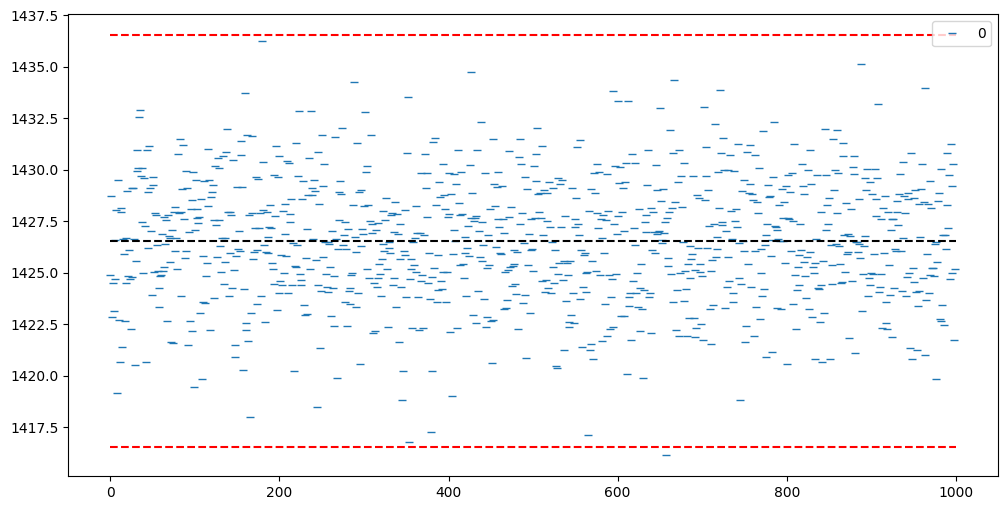

In [278]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
from scipy.stats import norm

# Supongamos que tienes definidos sigma, media e intervalo en tu código
sigma = 1082.7945490306845
media = 1426.5372144947232
intervalo = [1416.5372195108237, 1436.5372094786228]

tamano_simulacion = 1000
ingreso_5000 = datos.query('Ingreso <= 5000').Ingreso
z = norm.ppf(0.975)
e = 10
n = 45039

# Simulación de medias
medias = [ingreso_5000.sample(n=n).mean() for i in range(tamano_simulacion)]
medias = pd.DataFrame(medias)

# Imprimir datos para verificar
print("Media:", media)
print("Intervalo:", intervalo)
print("Primeras filas de medias:")
print(medias.head())

# Crear el gráfico
ax = medias.plot(style='_')
ax.figure.set_size_inches(12, 6)

# Línea horizontal para la media
ax.hlines(y=media, xmin=0, xmax=tamano_simulacion, colors='black', linestyles='--')

# Líneas horizontales para el intervalo de confianza
ax.hlines(y=intervalo[0], xmin=0, xmax=tamano_simulacion, colors='red', linestyles='--')
ax.hlines(y=intervalo[1], xmin=0, xmax=tamano_simulacion, colors='red', linestyles='--')

# Mostrar el gráfico
plt.show()
